# <span style="color:red"> **LSN - Esercitazione 07**
### <span style="color:green"> 24.04.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
Il codice di simulazione non è aggiornato con cose implementate nell'esercitazione 6.

#### Esercizio 07.1
- produrre valore di energia potenziale e pressione con tail aggiunte
- nelle formule delle tail ho messo $\epsilon = 1$: è corretto?
- devo moltiplicare $V_{tail}$ per N? (vedere formula slide 9 lecture 7) Ho fatto una simulazione con tail corrections moltiplicate per questi fattori, e vengono valori di U/N e p molto più piccoli di quelli che si ottengono senza correzioni. Questo mi fa pensare che non sia necessario moltiplicare per quei fattori
- devo moltiplicare $p_{tail}$ per 3N? (vedere formula slide 10 lecture 7)

#### Esercizio 07.2
- produrre valori di U/N e non di U: devo dunque dividere tutto per N=108? L'ho fatto, nel codice python. è corretto?
- incertezza statistica dell'autocorrelazione. devo calcolare valori e incertezze con data blocking?

#### Esercizio 07.3

#### Esercizio 07.4

## <span style="color:blue">**Esercizio 07.1**

Nella quarta esercitazione, si è fatta un'approssimazione fuori controllo: nel calcolo dell'energia potenziale, si è trascurato il valore dell'integrake tra $R_{cut}$ e $\infty$.Per un generico potenziale, l'equazione che descrive tali correzioni è:
$$ 
<V>_{tail} \, =  \, 2 \pi \rho N \int_{r_{cut}} ^{+ \infty} dr r^2 v(r) g(r) \, \approx \, 2 \pi \rho N \int_{r_{cut}} ^{+ \infty} dr r^2 v(r)
$$
Per valori di $R_{cut}$ sufficientemente grandi, le oscillazioni di $g(r)$ sono sempre più smorzate, ed è dunque lecito approssimare $g(r) \approx 1$. \
Nel caso di potenziale di Lennard-Jones, si ottiene:
$$
\frac{<V_{LJ}>_{tail}}{N} \, \approx  \, \frac{8 \pi \rho_{LJ} \epsilon}{9 r_{cut (LJ)}^9} - \frac{8 \pi \rho_{LJ} \epsilon}{3 r_{cut (LJ)}^3}
$$

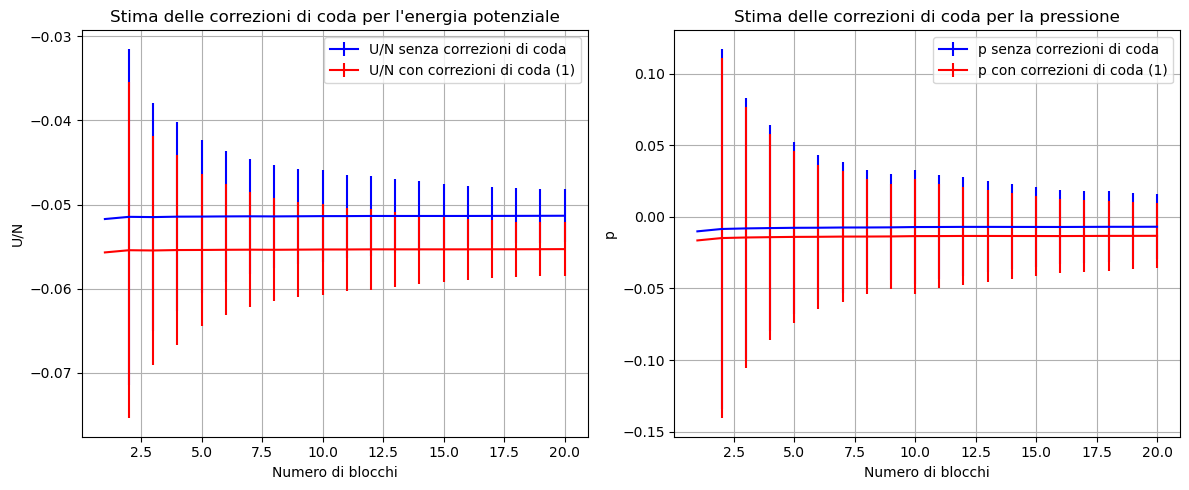

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

N = 108 # numero di particelle

# Carico i dati dal file
data_U_no = np.loadtxt("simulazioni-eseguite/07.1/OUTPUT_no_tail/potential_energy.dat") # energia potenziale senza correzioni di coda
data_p_no = np.loadtxt("simulazioni-eseguite/07.1/OUTPUT_no_tail/pressure.dat") # pressione senza correzioni di coda
data_U_tail_1 = np.loadtxt("simulazioni-eseguite/07.1/OUTPUT_tail_1/potential_energy.dat") # energia potenziale con correzioni di coda
data_p_tail_1 = np.loadtxt("simulazioni-eseguite/07.1/OUTPUT_tail_1/pressure.dat") # pressione senza correzioni di coda 

N_blocchi = data_U_no[:, 0]   # Prima colonna: contiene il numero di blocchi

U_no = data_U_no[:, 2]   # Terza colonna: contiene il valore medio di energia potenziale
error_U_no = data_U_no[:,3] # Quarta colonna: contiene l'errore
p_no = data_p_no[:, 2]   # Terza colonna: contiene il valore medio di pressione
error_p_no = data_p_no[:,3] # Quarta colonna: contiene l'errore

U_tail_1 = data_U_tail_1[:, 2]   # Terza colonna: contiene il valore medio di energia potenziale
error_U_tail_1 = data_U_tail_1[:,3] # Quarta colonna: contiene l'errore
p_tail_1 = data_p_tail_1[:, 2]   # Terza colonna: contiene il valore medio di pressione
error_p_tail_1= data_p_tail_1[:,3] # Quarta colonna: contiene l'errore


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

# Primo grafico
axes[0].errorbar(N_blocchi, U_no/N, yerr=error_U_no, color='b', label='U/N senza correzioni di coda')
axes[0].errorbar(N_blocchi, U_tail_1/N, yerr = error_U_tail_1,  color='r', label='U/N con correzioni di coda (1)' )
axes[0].set_title("Stima delle correzioni di coda per l'energia potenziale")
axes[0].set_xlabel("Numero di blocchi")
axes[0].set_ylabel("U/N")
axes[0].legend()
axes[0].grid(True)

# Secondo grafico
axes[1].errorbar(N_blocchi, p_no/N, yerr = error_p_no,  color='b', label='p senza correzioni di coda')
axes[1].errorbar(N_blocchi, p_tail_1/N, yerr = error_p_tail_1,  color='r', label='p con correzioni di coda (1)')
axes[1].set_title("Stima delle correzioni di coda per la pressione")
axes[1].set_xlabel("Numero di blocchi")
axes[1].set_ylabel("p")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Si è effettuata una simulazione ponendo le correzioni di coda per l'energia potenziale e per la pressione pari a 0, e successivamente si è effettuata una simulazione stimando le correzioni di coda con l'espressione nelle equazioni sopra. Si osserva che tali correzioni sono più piccole delle incertezze statistiche al valore medio, e dunque l'approssimazione effettuata nell'esercitazione 4 è legittima.

## <span style="color:blue">**Esercizio 07.2**

Perché il sistema si equilibrasse, ho scartato i primi 5.000 steps (cioè ho fatto una simulazione di equilibrazione con 5.000 steps, e poi sono ripartita dal punto finale di questa simulazione come punto di partenza per i dati che effettivamente prendo). Ho fatto simulazione con 500.000 blocchi da 1 step.
Per simulazione MC, osservo che con delta = 0.1 ottengo accettazione del 50%, come richiesto.

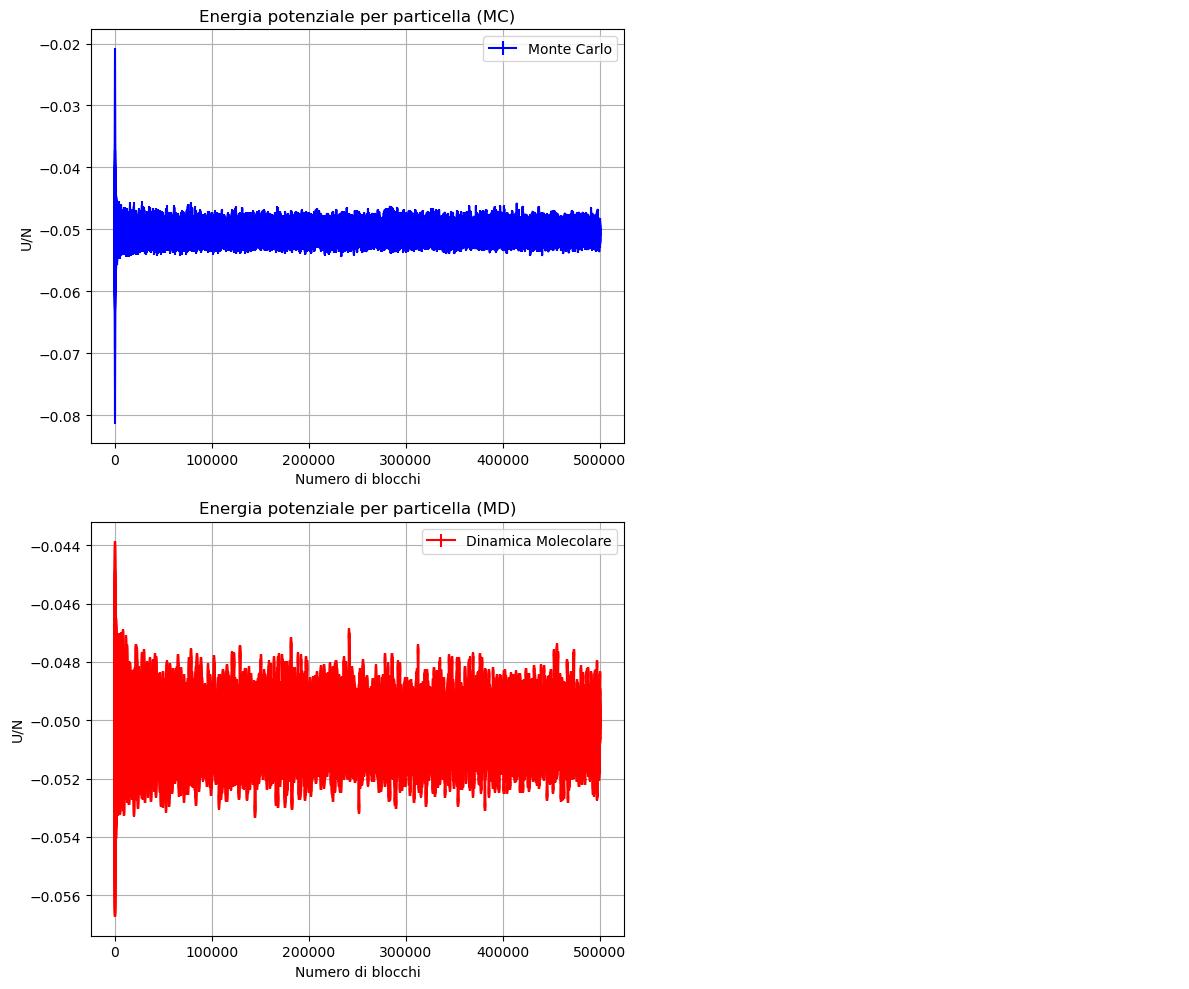

In [39]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

N = 108  # Numero totale di particelle

# Carico i dati dal file
data_U_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
# data_p_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/pressure.dat")
data_U_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")
# data_p_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/pressure.dat")

# Estraggo le colonne di dati
x = data_U_MC[:, 0]         # Prima colonna: numero di blocchi
y_U_MC = data_U_MC[:, 1]    # Seconda colonna: valori istantanei
err_U_MC = data_U_MC[:, 3]  # Quarta colonna: errore

# y_p_MC = data_p_MC[:, 1]
# err_p_MC = data_p_MC[:, 3]

y_U_MD = data_U_MD[:, 1]
err_U_MD = data_U_MD[:, 3]

# y_p_MD = data_p_MD[:, 1]
# err_p_MD = data_p_MD[:, 3]

# Creazione di una figura con 2 righe e 2 colonne
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# U/N Monte Carlo
axes[0, 0].errorbar(x, y_U_MC/N, yerr=err_U_MC, color='b', label='Monte Carlo')
axes[0, 0].set_xlabel("Numero di blocchi")
axes[0, 0].set_ylabel("U/N")
axes[0, 0].set_title("Energia potenziale per particella (MC)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Pressione Monte Carlo
# axes[0, 1].errorbar(x, y_p_MC, yerr=err_p_MC, color='g', label='Monte Carlo')
# axes[0, 1].set_xlabel("Numero di blocchi")
# axes[0, 1].set_ylabel("p")
# axes[0, 1].set_title("Pressione (MC)")
# axes[0, 1].legend()
# axes[0, 1].grid(True)

# U/N Dinamica Molecolare
axes[1, 0].errorbar(x, y_U_MD/N, yerr=err_U_MD, color='r', label='Dinamica Molecolare')
axes[1, 0].set_xlabel("Numero di blocchi")
axes[1, 0].set_ylabel("U/N")
axes[1, 0].set_title("Energia potenziale per particella (MD)")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Pressione Dinamica Molecolare
# axes[1, 1].errorbar(x, y_p_MD, yerr=err_p_MD, color='orange', label='Molecolare')
# axes[1, 1].set_xlabel("Numero di blocchi")
# axes[1, 1].set_ylabel("p")
# axes[1, 1].set_title("Pressione (MD)")
# axes[1, 1].legend()
# axes[1, 1].grid(True)

# Rimuovo il subplot vuoto se non uso [0,1] e [1,1]
axes[0, 1].axis('off')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


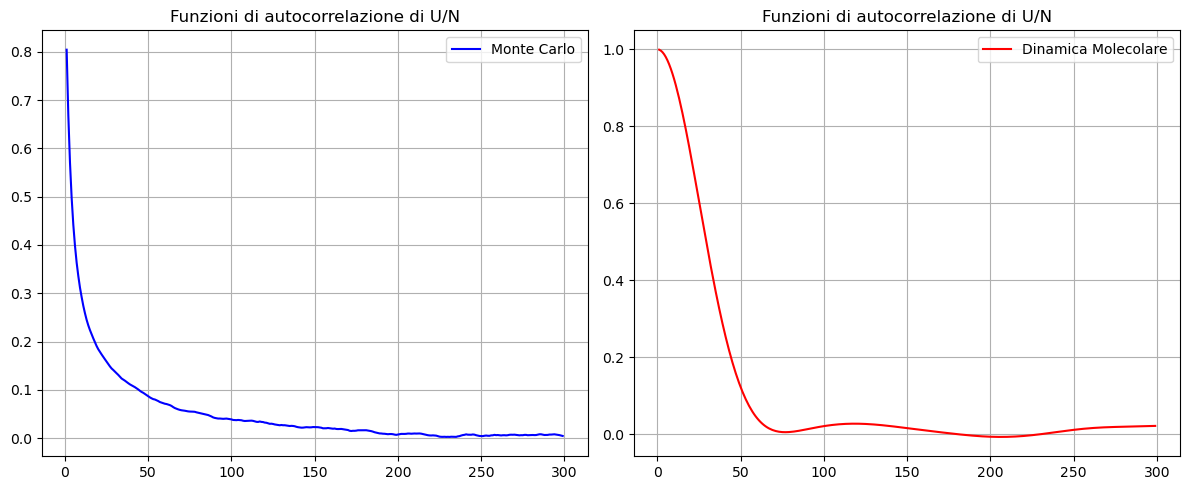

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
data_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data_MC[:, 0]   # Prima colonna: contiene il numero di blocchi
U_MC = data_MC[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
U_MD = data_MD[:, 1]
autocorrelation_MC = [] # Array per contenere il valore della autocorrelazione
autocorrelation_MD = []
t_calcolati = []

for i in range(1,300):
    a_MC = 0.0
    a_MD = 0.0
    b_MC = 0.0
    b_MD = 0.0
    c_MC = 0.0
    c_MD = 0.0
    d_MC = 0.0
    d_MD = 0.0
    e_MC = 0.0
    e_MD = 0.0
    for j in range( t_max - i ):
        a_MC += U_MC[j] * U_MC[j+i]
        a_MD += U_MD[j] * U_MD[j+i]
        b_MC += U_MC[j]
        b_MD += U_MD[j]
        c_MC += U_MC[j+i]
        c_MD += U_MD[j+i]
    for k in range ( t_max):
        d_MC += U_MC[k] * U_MC[k]
        d_MD += U_MD[k] * U_MD[k]
        e_MC += U_MC[k]
        e_MD += U_MD[k]
    autocorrelation_MC.append(( (1. / (t_max - i) * a_MC ) - 1./(t_max - i) * b_MC * 1./(t_max - i) * c_MC ) / ( (1./ t_max) * d_MC - ( (1./ t_max) * e_MC )**2 ))
    autocorrelation_MD.append(( (1. / (t_max - i) * a_MD ) - 1./(t_max - i) * b_MD * 1./(t_max - i) * c_MD ) / ( (1./ t_max) * d_MD - ( (1./ t_max) * e_MD )**2 ))
    t_calcolati.append(i)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

# Primo grafico
axes[0].plot(t_calcolati, autocorrelation_MC,  color='b', label='Monte Carlo')
axes[0].set_title("Funzioni di autocorrelazione di U/N")
axes[0].legend()
axes[0].grid(True)

# Secondo grafico
axes[1].plot(t_calcolati, autocorrelation_MD,  color='r', label='Dinamica Molecolare')
axes[1].set_title("Funzioni di autocorrelazione di U/N")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


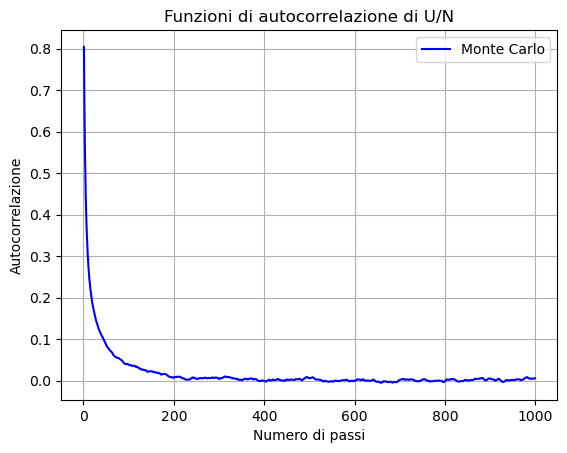

In [51]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data[:, 0]   # Prima colonna: contiene il numero di blocchi
U = data[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
autocorrelation = [] # Array per contenere il valore della autocorrelazione
t_calcolati = []

for i in range(1,1000):
    a = 0.0
    b = 0.0
    c = 0.0
    d = 0.0
    e = 0.0
    for j in range( t_max - i ):
        a += U[j] * U[j+i]
        b += U[j]
        c += U[j+i]
    for k in range ( t_max):
        d += U[k] * U[k]
        e += U[k]
    autocorrelation.append(( (1. / (t_max - i) * a ) - 1./(t_max - i) * b * 1./(t_max - i) * c ) / ( (1./ t_max) * d - ( (1./ t_max) * e )**2 ))
    t_calcolati.append(i)

plt.errorbar(t_calcolati, autocorrelation,  color='b', label='Monte Carlo')
plt.title("Funzioni di autocorrelazione di U/N")
plt.xlabel("Numero di passi")
plt.ylabel("Autocorrelazione")
plt.legend()
plt.grid(True)
plt.show()


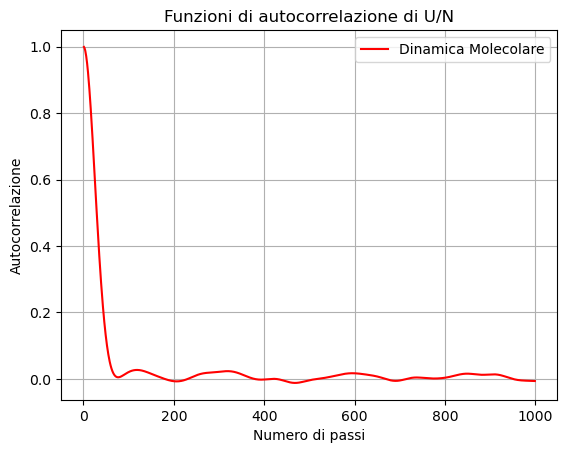

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data[:, 0]   # Prima colonna: contiene il numero di blocchi
U = data[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
autocorrelation = [] # Array per contenere il valore della autocorrelazione
t_calcolati = []

for i in range(1,1000):
    a = 0.0
    b = 0.0
    c = 0.0
    d = 0.0
    e = 0.0
    for j in range( t_max - i ):
        a += U[j] * U[j+i]
        b += U[j]
        c += U[j+i]
    for k in range ( t_max):
        d += U[k] * U[k]
        e += U[k]
    autocorrelation.append(( (1. / (t_max - i) * a ) - 1./(t_max - i) * b * 1./(t_max - i) * c ) / ( (1./ t_max) * d - ( (1./ t_max) * e )**2 ))
    t_calcolati.append(i)

plt.errorbar(t_calcolati, autocorrelation,  color='r', label='Dinamica Molecolare')
plt.title("Funzioni di autocorrelazione di U/N")
plt.xlabel("Numero di passi")
plt.ylabel("Autocorrelazione")
plt.legend()
plt.grid(True)
plt.show()


Dopo 200 passi, le funzioni di autocorrelazione di $U/N$ nel caso di simulazione Monte Carlo e di Dinamica Molecolare sono compatibili con 0. Tali simulazioni, dunque, impiegano circa 200 timestep o passi Monte Carlo a scorrelarsi. 

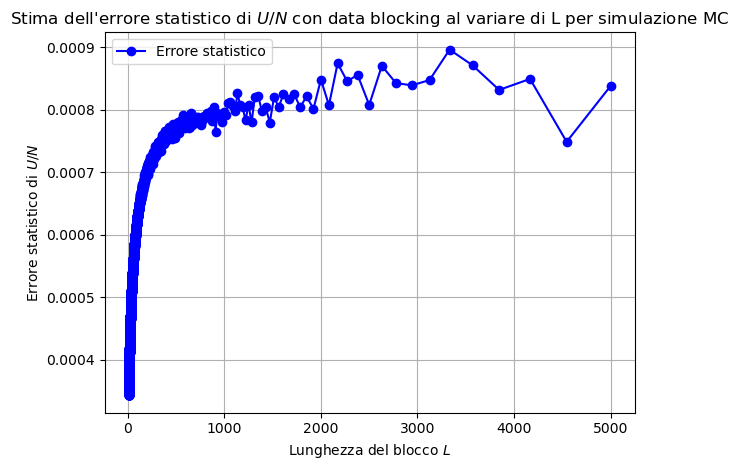

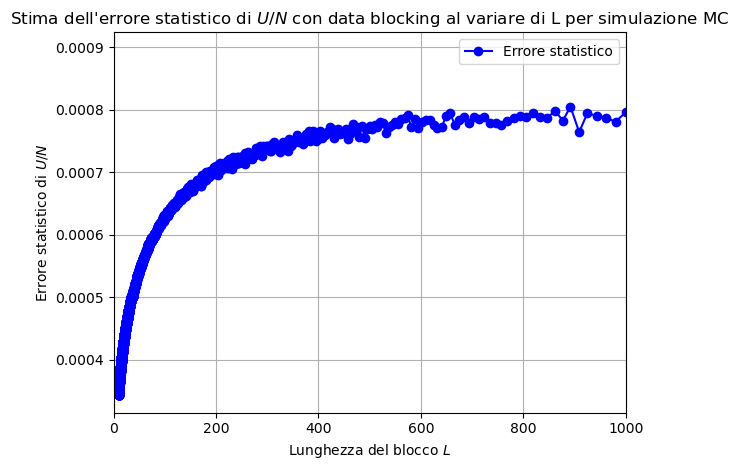

In [23]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
observable = data[:, 1]  # carico i valori istantanei di U/N
M = len(observable) # M è il numero di simulazioni effettuate in totale

# Definisco il numero di blocchi da testare
N_values = np.arange(100, 50000, 10) 
errors = []
L_values = []

for N in N_values:
    L = M // N  # lunghezza del blocco
    if L == 0:
        continue  # salta se ci sono troppi blocchi

    block_avgs = np.array([np.mean(observable[i*L:(i+1)*L]) for i in range(N)]) # creo un array che ha, in ogni elemento, la media di ciascun blocco
    # partiziona gli M elementi totali in N blocchi da L elementi (0-L, L-2L, ..., (N-1)L-NL), e fa la media degli elementi di ciascun blocco
    mean = np.mean(block_avgs) # calcola la media totale delle medie di ciascun blocco
    std_err = np.sqrt(np.var(block_avgs, ddof=1) / N) # calcola l'errore associato a ogni media totale come deviazione standard
    errors.append(std_err)
    L_values.append(L)

plt.plot(L_values, errors, marker='o', color = 'b', linestyle='-', label='Errore statistico')
plt.xlabel("Lunghezza del blocco $L$")
plt.ylabel("Errore statistico di $U/N$")
plt.title("Stima dell'errore statistico di $U/N$ con data blocking al variare di L per simulazione MC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(L_values, errors, marker='o', color = 'b', linestyle='-', label='Errore statistico')
plt.xlabel("Lunghezza del blocco $L$")
plt.ylabel("Errore statistico di $U/N$")
plt.xlim(0,1000)
plt.title("Stima dell'errore statistico di $U/N$ con data blocking al variare di L per simulazione MC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


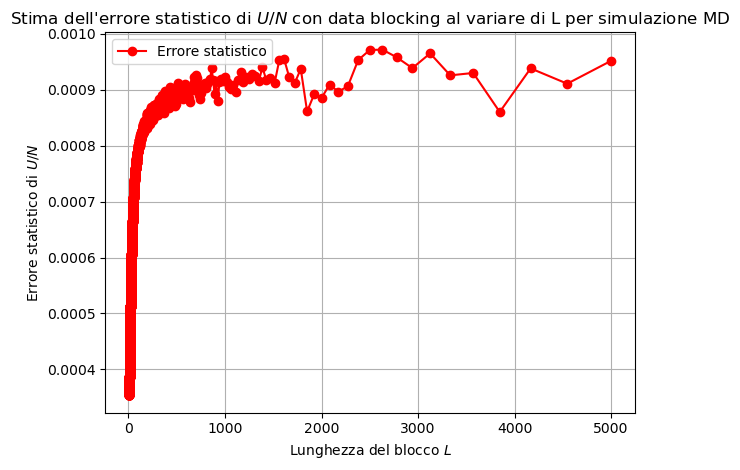

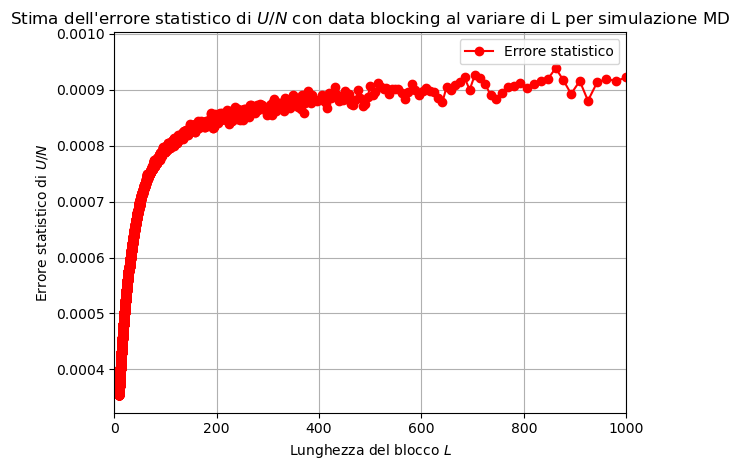

In [22]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")
observable = data[:, 1]  # carico i valori istantanei di U/N
M = len(observable) # M è il numero di simulazioni effettuate in totale

# Definisco il numero di blocchi da testare
N_values = np.arange(100, 50000, 10) 
errors = []
L_values = []

for N in N_values:
    L = M // N  # lunghezza del blocco
    if L == 0:
        continue  # salta se ci sono troppi blocchi

    block_avgs = np.array([np.mean(observable[i*L:(i+1)*L]) for i in range(N)]) # creo un array che ha, in ogni elemento, la media di ciascun blocco
    # partiziona gli M elementi totali in N blocchi da L elementi (0-L, L-2L, ..., (N-1)L-NL), e fa la media degli elementi di ciascun blocco
    mean = np.mean(block_avgs) # calcola la media totale delle medie di ciascun blocco
    std_err = np.sqrt(np.var(block_avgs, ddof=1) / N) # calcola l'errore associato a ogni media totale come deviazione standard
    errors.append(std_err)
    L_values.append(L)

plt.plot(L_values, errors, marker='o', color = 'r', linestyle='-', label='Errore statistico')
plt.xlabel("Lunghezza del blocco $L$")
plt.ylabel("Errore statistico di $U/N$")
plt.title("Stima dell'errore statistico di $U/N$ con data blocking al variare di L per simulazione MD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(L_values, errors, marker='o', color = 'r', linestyle='-', label='Errore statistico')
plt.xlabel("Lunghezza del blocco $L$")
plt.ylabel("Errore statistico di $U/N$")
plt.xlim(0,1000)
plt.title("Stima dell'errore statistico di $U/N$ con data blocking al variare di L per simulazione MD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Osservo che ottengo, per piccoli valori di $L$, incertezze piccole, che poi crescono all'aumentare di L, fino a stabilizzarsi. Da $L=600$, il valore delle incertezze statistiche rimane costante. Per stimare bene l'incertezza statistica, dunque, è necessario effettuare data blocking con blocchi costituiti da $600$ step.

## <span style="color:blue">**Esercizio 07.3**

## <span style="color:blue">**Esercizio 07.4**